# Lane Boundary Detection Evaluation

Evaluates predicted lane boundary detection results against manually annotated ground truth
using cross-section intersections.

**Approach:**
- Each cross section intersects both GT and predicted lane lines
- Intersection geometries are converted to points
- Nearest-neighbor matching pairs GT points to predicted points (max 0.5 m)
- Unmatched GT points are false negatives; unmatched predictions are false positives

**Metrics:**
1. Detection quality (Precision, Recall, F1)
2. Positional accuracy (Mean, RMSE, Median, P95, Max error)
3. Semantic classification quality (solid vs dashed)
4. Topology / lane count consistency

**Output:**
- `eval.gpkg` with layers: `semantic_match`, `positional_match`, `false_negative`, `false_positive`

## Setup

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
from shapely.geometry import Point, MultiPoint
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## Configuration

In [ ]:
# Maximum matching radius in meters
MATCH_THRESHOLD = 0.2

# Target CRS for all spatial operations
TARGET_CRS = "EPSG:23700"

# Input file paths (relative to notebook location)
GT_LANES_PATH = "../../../data/manual_annotation/lanes.gpkg"
CROSS_SECTIONS_PATH = "../../../data/manual_annotation/cross_sections.gpkg"
PREDICTED_LANES_PATH = "../../../data/output/cegl_2/output_bin_40/8_lane_lines_labeled.gpkg"

# Output GeoPackage (same folder as notebook)
OUTPUT_GPKG = Path("eval.gpkg")

## Load and Reproject Data

In [3]:
# Load GeoPackages and transform to target CRS
gt_lanes = gpd.read_file(GT_LANES_PATH).to_crs(TARGET_CRS)
cross_sections = gpd.read_file(CROSS_SECTIONS_PATH).to_crs(TARGET_CRS)
pred_lanes = gpd.read_file(PREDICTED_LANES_PATH).to_crs(TARGET_CRS)

print(f"GT lanes: {len(gt_lanes)} features")
print(f"Cross sections: {len(cross_sections)} features")
print(f"Predicted lanes: {len(pred_lanes)} features")
print(f"\nGT lane types: {gt_lanes['type'].value_counts().to_dict()}")
print(f"Predicted lane types: {pred_lanes['type'].value_counts().to_dict()}")

GT lanes: 6 features
Cross sections: 467 features
Predicted lanes: 34 features

GT lane types: {'solid': 4, 'dashed': 2}
Predicted lane types: {'solid': 23, 'dashed': 11}


/Users/kada.haala/Projects/thesis/lane-detection/.venv/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'lanes.gpkg': 'lanes' (default), 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(


## Helper Functions

In [4]:
def extract_intersection_points(cross_section_geom, lane_gdf):
    """
    Compute intersection points between a cross section line and lane geometries.

    Returns a list of dicts with:
        - 'point': Shapely Point geometry of the intersection
        - 'type': lane marking type ('solid' or 'dashed')
    """
    intersections = []

    for _, lane in lane_gdf.iterrows():
        lane_geom = lane.geometry
        if lane_geom is None or lane_geom.is_empty:
            continue

        intersection = cross_section_geom.intersection(lane_geom)

        if intersection.is_empty:
            continue

        # Collect all points from the intersection result
        points = []
        if intersection.geom_type == "Point":
            points = [intersection]
        elif intersection.geom_type == "MultiPoint":
            points = list(intersection.geoms)
        # Skip non-point intersections (e.g., collinear overlaps)

        for pt in points:
            intersections.append({
                "point": pt,
                "type": lane.get("type", None),
            })

    return intersections

In [5]:
def match_intersections(gt_intersections, pred_intersections, threshold):
    """
    Match GT to predicted intersection points using nearest-neighbor matching.

    For each GT point, find the closest unmatched prediction point within the
    threshold radius (Euclidean distance). Each prediction point can only be
    matched once.

    Returns:
        matched_pairs: list of (gt_idx, pred_idx, distance) tuples
        unmatched_gt: list of GT indices (false negatives)
        unmatched_pred: list of prediction indices (false positives)
    """
    if len(gt_intersections) == 0 and len(pred_intersections) == 0:
        return [], [], []

    if len(gt_intersections) == 0:
        return [], [], list(range(len(pred_intersections)))

    if len(pred_intersections) == 0:
        return [], list(range(len(gt_intersections))), []

    # Build Euclidean distance matrix between all GT and prediction points
    gt_coords = np.array([[g["point"].x, g["point"].y] for g in gt_intersections])
    pred_coords = np.array([[p["point"].x, p["point"].y] for p in pred_intersections])

    # dist_matrix[i, j] = Euclidean distance between GT_i and Pred_j
    diff = gt_coords[:, np.newaxis, :] - pred_coords[np.newaxis, :, :]
    dist_matrix = np.sqrt((diff ** 2).sum(axis=2))

    matched_pairs = []
    matched_gt = set()
    matched_pred = set()

    # Greedy nearest-neighbor: iteratively pick the globally closest valid pair
    while True:
        # Mask already-matched entries
        masked = dist_matrix.copy()
        for i in matched_gt:
            masked[i, :] = np.inf
        for j in matched_pred:
            masked[:, j] = np.inf

        # Find the closest remaining pair
        min_idx = np.unravel_index(np.argmin(masked), masked.shape)
        min_dist = masked[min_idx]

        if min_dist > threshold:
            break

        gt_idx, pred_idx = int(min_idx[0]), int(min_idx[1])
        matched_pairs.append((gt_idx, pred_idx, min_dist))
        matched_gt.add(gt_idx)
        matched_pred.add(pred_idx)

    unmatched_gt = [i for i in range(len(gt_intersections)) if i not in matched_gt]
    unmatched_pred = [i for i in range(len(pred_intersections)) if i not in matched_pred]

    return matched_pairs, unmatched_gt, unmatched_pred

## Run Evaluation on All Cross Sections

In [6]:
# Collect evaluation results across all cross sections
all_matched_pairs = []  # dicts with gt_type, pred_type, distance, gt_point, pred_point
all_fn = []             # false negative records (unmatched GT)
all_fp = []             # false positive records (unmatched predictions)
cross_section_stats = []  # per cross-section lane counts

for cs_idx, cs_row in cross_sections.iterrows():
    cs_geom = cs_row.geometry
    if cs_geom is None or cs_geom.is_empty:
        continue

    # Intersect cross section with GT and predicted lane lines
    gt_ints = extract_intersection_points(cs_geom, gt_lanes)
    pred_ints = extract_intersection_points(cs_geom, pred_lanes)

    # Match GT to predicted using nearest-neighbor within threshold
    matched, unmatched_gt, unmatched_pred = match_intersections(
        gt_ints, pred_ints, MATCH_THRESHOLD
    )

    # Store matched pairs with types, distances, and geometries
    for gt_i, pred_i, dist in matched:
        all_matched_pairs.append({
            "gt_type": gt_ints[gt_i]["type"],
            "pred_type": pred_ints[pred_i]["type"],
            "distance": dist,
            "gt_point": gt_ints[gt_i]["point"],
            "pred_point": pred_ints[pred_i]["point"],
        })

    # Store false negatives (unmatched GT points)
    for gt_i in unmatched_gt:
        all_fn.append({
            "gt_type": gt_ints[gt_i]["type"],
            "point": gt_ints[gt_i]["point"],
        })

    # Store false positives (unmatched prediction points)
    for pred_i in unmatched_pred:
        all_fp.append({
            "pred_type": pred_ints[pred_i]["type"],
            "point": pred_ints[pred_i]["point"],
        })

    # Per cross-section lane counts for topology analysis
    cross_section_stats.append({
        "gt_count": len(gt_ints),
        "pred_count": len(pred_ints),
    })

# Summary counts
TP = len(all_matched_pairs)
FP = len(all_fp)
FN = len(all_fn)

print(f"Evaluation complete over {len(cross_section_stats)} cross sections.")
print(f"  True Positives:  {TP}")
print(f"  False Positives: {FP}")
print(f"  False Negatives: {FN}")

Evaluation complete over 467 cross sections.
  True Positives:  1360
  False Positives: 14
  False Negatives: 34


---
## Metric 1 — Detection Quality

Measures how well the pipeline detects lane boundary intersections across cross sections.
- **Precision**: fraction of predicted intersections that are correct
- **Recall**: fraction of GT intersections that are detected
- **F1-score**: harmonic mean of precision and recall

In [7]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# Detection metrics table
detection_metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Value": [f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}"],
})

print("=" * 40)
print("  DETECTION QUALITY METRICS")
print("=" * 40)
print(detection_metrics.to_string(index=False))

# Confusion-style summary
confusion_summary = pd.DataFrame({
    "Category": ["True Positives (TP)", "False Positives (FP)", "False Negatives (FN)"],
    "Count": [TP, FP, FN],
})
print("\n" + "=" * 40)
print("  TP / FP / FN SUMMARY")
print("=" * 40)
print(confusion_summary.to_string(index=False))

  DETECTION QUALITY METRICS
   Metric  Value
Precision 0.9898
   Recall 0.9756
 F1-Score 0.9827

  TP / FP / FN SUMMARY
            Category  Count
 True Positives (TP)   1360
False Positives (FP)     14
False Negatives (FN)     34


---
## Metric 2 — Positional Accuracy

For matched pairs (True Positives), compute the Euclidean distance between the GT
intersection point and the predicted intersection point.

In [8]:
if len(all_matched_pairs) > 0:
    errors = np.array([m["distance"] for m in all_matched_pairs])

    mean_error = np.mean(errors)
    rmse = np.sqrt(np.mean(errors ** 2))
    median_error = np.median(errors)
    p95_error = np.percentile(errors, 95)
    max_error = np.max(errors)

    positional_metrics = pd.DataFrame({
        "Metric": ["Mean Error", "RMSE", "Median Error", "P95 Error", "Max Error"],
        "Value (m)": [
            f"{mean_error:.4f}",
            f"{rmse:.4f}",
            f"{median_error:.4f}",
            f"{p95_error:.4f}",
            f"{max_error:.4f}",
        ],
    })
    print("=" * 40)
    print("  POSITIONAL ACCURACY METRICS")
    print("=" * 40)
    print(positional_metrics.to_string(index=False))
else:
    print("No matched pairs — cannot compute positional accuracy.")
    errors = np.array([])

  POSITIONAL ACCURACY METRICS
      Metric Value (m)
  Mean Error    0.0228
        RMSE    0.0307
Median Error    0.0172
   P95 Error    0.0589
   Max Error    0.1832


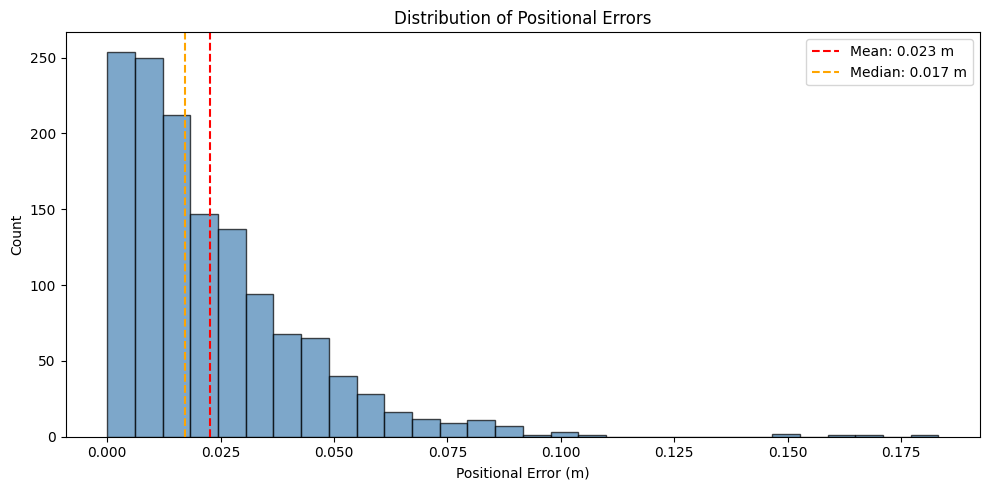

In [9]:
# Histogram of positional errors
if len(errors) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(errors, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(mean_error, color="red", linestyle="--", label=f"Mean: {mean_error:.3f} m")
    ax.axvline(median_error, color="orange", linestyle="--", label=f"Median: {median_error:.3f} m")
    ax.set_xlabel("Positional Error (m)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Positional Errors")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Metric 3 — Semantic Classification Accuracy

For matched pairs, compare GT `type` vs predicted `type` (solid / dashed).
Compute confusion matrix, classification accuracy, precision, recall, F1 per class.

In [10]:
if len(all_matched_pairs) > 0:
    gt_types = [m["gt_type"] for m in all_matched_pairs]
    pred_types = [m["pred_type"] for m in all_matched_pairs]

    # Filter out pairs where either type is None
    valid_mask = [(g is not None and p is not None) for g, p in zip(gt_types, pred_types)]
    gt_types_valid = [g for g, v in zip(gt_types, valid_mask) if v]
    pred_types_valid = [p for p, v in zip(pred_types, valid_mask) if v]

    if len(gt_types_valid) > 0:
        labels = sorted(set(gt_types_valid + pred_types_valid))

        acc = accuracy_score(gt_types_valid, pred_types_valid)

        print("=" * 40)
        print("  CLASSIFICATION METRICS")
        print("=" * 40)
        print(f"  Overall Accuracy: {acc:.4f}")
        print()
        print("Per-class report:")
        print(classification_report(
            gt_types_valid, pred_types_valid, labels=labels, zero_division=0
        ))
    else:
        print("No valid type labels available for classification evaluation.")
else:
    print("No matched pairs — cannot compute classification metrics.")

  CLASSIFICATION METRICS
  Overall Accuracy: 0.9971

Per-class report:
              precision    recall  f1-score   support

      dashed       0.99      1.00      1.00       440
       solid       1.00      1.00      1.00       920

    accuracy                           1.00      1360
   macro avg       1.00      1.00      1.00      1360
weighted avg       1.00      1.00      1.00      1360



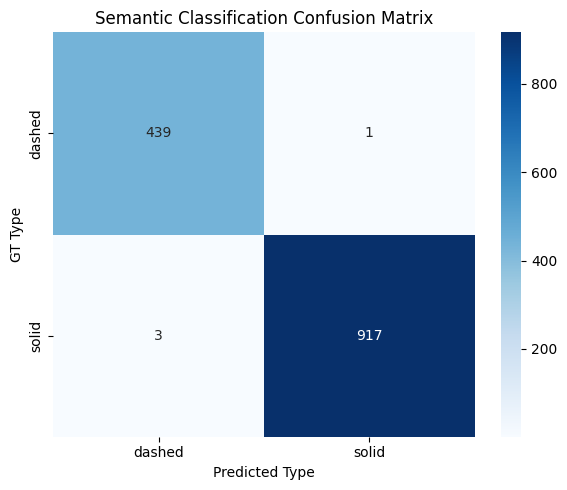

In [11]:
# Confusion matrix display
if len(all_matched_pairs) > 0 and len(gt_types_valid) > 0:
    cm = confusion_matrix(gt_types_valid, pred_types_valid, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_xlabel("Predicted Type")
    ax.set_ylabel("GT Type")
    ax.set_title("Semantic Classification Confusion Matrix")
    plt.tight_layout()
    plt.show()

---
## Metric 4 — Topology Consistency

For every cross section, compare the number of GT intersections to the number of
prediction intersections. Measures structural consistency of lane detection.

In [12]:
stats_df = pd.DataFrame(cross_section_stats)

if len(stats_df) > 0:
    stats_df["count_diff"] = stats_df["pred_count"] - stats_df["gt_count"]
    stats_df["abs_count_diff"] = stats_df["count_diff"].abs()

    mean_abs_error = stats_df["abs_count_diff"].mean()
    perfect_match_pct = (stats_df["abs_count_diff"] == 0).mean() * 100

    topology_metrics = pd.DataFrame({
        "Metric": [
            "Mean Absolute Lane Count Error",
            "Perfectly Matched Cross Sections (%)",
            "Total Cross Sections Evaluated",
        ],
        "Value": [
            f"{mean_abs_error:.3f}",
            f"{perfect_match_pct:.1f}%",
            f"{len(stats_df)}",
        ],
    })
    print("=" * 45)
    print("  TOPOLOGY / LANE COUNT CONSISTENCY")
    print("=" * 45)
    print(topology_metrics.to_string(index=False))
else:
    print("No cross section stats available.")

  TOPOLOGY / LANE COUNT CONSISTENCY
                              Metric Value
      Mean Absolute Lane Count Error 0.043
Perfectly Matched Cross Sections (%) 96.1%
      Total Cross Sections Evaluated   467


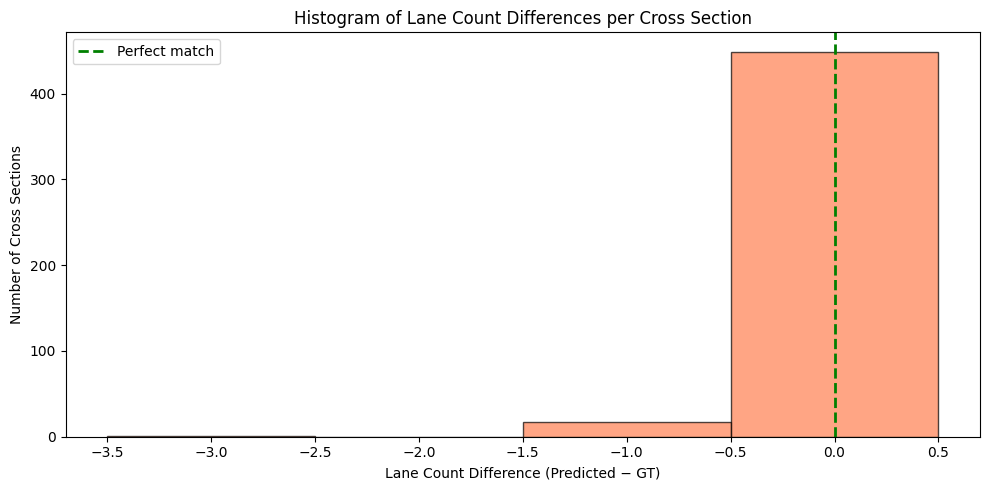

In [13]:
# Histogram of lane count differences
if len(stats_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    diff_values = stats_df["count_diff"]
    bins = np.arange(diff_values.min() - 0.5, diff_values.max() + 1.5, 1)

    ax.hist(diff_values, bins=bins, edgecolor="black", alpha=0.7, color="coral")
    ax.axvline(0, color="green", linestyle="--", linewidth=2, label="Perfect match")
    ax.set_xlabel("Lane Count Difference (Predicted \u2212 GT)")
    ax.set_ylabel("Number of Cross Sections")
    ax.set_title("Histogram of Lane Count Differences per Cross Section")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Output GeoPackage

Write evaluation results to `eval.gpkg` with the following layers:
- `semantic_match`: matched pairs where distance <= 0.5 m AND lane types match
- `positional_match`: matched pairs where distance <= 0.5 m BUT lane types differ
- `false_negative`: GT points that were not matched
- `false_positive`: prediction points that were not matched

In [14]:
# --- Layer: semantic_match ---
# Matched pairs where distance <= threshold AND types match
semantic_records = []
for m in all_matched_pairs:
    if m["distance"] <= MATCH_THRESHOLD and m["gt_type"] == m["pred_type"]:
        semantic_records.append({
            "geometry": m["pred_point"],
            "gt_type": m["gt_type"],
            "pred_type": m["pred_type"],
            "distance": m["distance"],
        })

if semantic_records:
    semantic_gdf = gpd.GeoDataFrame(semantic_records, crs=TARGET_CRS)
else:
    semantic_gdf = gpd.GeoDataFrame(columns=["geometry", "gt_type", "pred_type", "distance"], geometry="geometry", crs=TARGET_CRS)
print(f"semantic_match: {len(semantic_gdf)} features")

# --- Layer: positional_match ---
# Matched pairs where distance <= threshold BUT types differ
positional_records = []
for m in all_matched_pairs:
    if m["distance"] <= MATCH_THRESHOLD and m["gt_type"] != m["pred_type"]:
        positional_records.append({
            "geometry": m["pred_point"],
            "gt_type": m["gt_type"],
            "pred_type": m["pred_type"],
            "distance": m["distance"],
        })

if positional_records:
    positional_gdf = gpd.GeoDataFrame(positional_records, crs=TARGET_CRS)
else:
    positional_gdf = gpd.GeoDataFrame(columns=["geometry", "gt_type", "pred_type", "distance"], geometry="geometry", crs=TARGET_CRS)
print(f"positional_match: {len(positional_gdf)} features")

# --- Layer: false_negative ---
# GT points that were not matched to any prediction
fn_records = []
for fn in all_fn:
    fn_records.append({
        "geometry": fn["point"],
        "gt_type": fn["gt_type"],
    })

if fn_records:
    fn_gdf = gpd.GeoDataFrame(fn_records, crs=TARGET_CRS)
else:
    fn_gdf = gpd.GeoDataFrame(columns=["geometry", "gt_type"], geometry="geometry", crs=TARGET_CRS)
print(f"false_negative: {len(fn_gdf)} features")

# --- Layer: false_positive ---
# Prediction points that were not matched to any GT
fp_records = []
for fp in all_fp:
    fp_records.append({
        "geometry": fp["point"],
        "pred_type": fp["pred_type"],
    })

if fp_records:
    fp_gdf = gpd.GeoDataFrame(fp_records, crs=TARGET_CRS)
else:
    fp_gdf = gpd.GeoDataFrame(columns=["geometry", "pred_type"], geometry="geometry", crs=TARGET_CRS)
print(f"false_positive: {len(fp_gdf)} features")

semantic_match: 1356 features
positional_match: 4 features
false_negative: 34 features
false_positive: 14 features


In [15]:
# Remove existing output file if present, then write all layers
if OUTPUT_GPKG.exists():
    OUTPUT_GPKG.unlink()

semantic_gdf.to_file(OUTPUT_GPKG, layer="semantic_match", driver="GPKG")
positional_gdf.to_file(OUTPUT_GPKG, layer="positional_match", driver="GPKG")
fn_gdf.to_file(OUTPUT_GPKG, layer="false_negative", driver="GPKG")
fp_gdf.to_file(OUTPUT_GPKG, layer="false_positive", driver="GPKG")

print(f"\nOutput written to: {OUTPUT_GPKG.resolve()}")
print(f"Layers: {', '.join(gpd.list_layers(OUTPUT_GPKG)['name'].tolist())}")


Output written to: /Users/kada.haala/Projects/thesis/lane-detection/evaluation/lanes/intensity_10/eval.gpkg
Layers: semantic_match, positional_match, false_negative, false_positive
